In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import time
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
zip_path = "/content/drive/MyDrive/car_prices.zip"
# Extract to Colab's local storage
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')
    print("Extracted files:", zip_ref.namelist())

Extracted files: ['car_prices.csv']


In [5]:
file_path = "/content/car_prices.csv"
df = pd.read_csv(file_path)

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Dataset loaded successfully!
Shape: 3722 rows, 20 columns

First 5 rows:
                     car_id    price fuel type  gear type        Make  \
0  icwAaDOmX573WiRRnLFPT237  2812500    Petrol  Automatic      Toyota   
1  ByZ3NlPy2x0arAIyrKazClUS  5000000    Petrol  Automatic       Acura   
2  2zG6Mh3kwyoTvWoeKHkV1oFH  7592000    Petrol  Automatic       Acura   
3  7APLHOPlI93qsYK0ST4D4wB2  9880000    Petrol  Automatic  Land Rover   
4   zIrIDPJLd46eRQf9JFacc0e  4160000    Petrol  Automatic        Ford   

         Model  Year of manufacture  Colour      Condition   Mileage  \
0      Corolla                 2004  Silver  Nigerian Used  251732.0   
1          MDX                 2007   Green   Foreign Used  224589.0   
2           TL                 2012   White   Foreign Used  111334.0   
3  Range Rover                 2012    Gray  Nigerian Used   72682.0   
4         Edge                 2013    Gray  Nigerian Used   92118.0   

   Engine Size Selling Condition Bought Condition    ca

In [19]:
print("\n" + "="*60)
print(" BASIC INFORMATION")
print("="*60)

print("\nData Info:")
df.info()

print("\nStatistical Summary of Numerical Features:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())


 BASIC INFORMATION

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3722 entries, 0 to 3721
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_id               3722 non-null   object 
 1   price                3722 non-null   int64  
 2   fuel type            3721 non-null   object 
 3   gear type            3720 non-null   object 
 4   Make                 3722 non-null   object 
 5   Model                3722 non-null   object 
 6   Year of manufacture  3722 non-null   int64  
 7   Colour               3717 non-null   object 
 8   Condition            3722 non-null   object 
 9   Mileage              3663 non-null   float64
 10  Engine Size          3661 non-null   float64
 11  Selling Condition    3722 non-null   object 
 12  Bought Condition     3722 non-null   object 
 13  car                  1767 non-null   object 
 14  Trim                 879 non-null    object 
 15  Drivet

,price,Year of manufacture,Mileage,Engine Size,Seats,Number of Cylinders,Horse Power
count,3.722000e+03,3722.000000,3.663000e+03,3.661000e+03,788.000000,826.000000,755.000000
mean,4.514644e+06,2008.145889,1.949841e+05,1.108062e+04,5.285533,5.157385,208.831788
std,4.297012e+06,4.205670,1.395755e+05,1.091127e+05,0.800853,1.202795,70.940925
min,5.500000e+05,1979.000000,1.000000e+00,1.800000e+02,2.000000,4.000000,83.000000
25%,2.310000e+06,2005.000000,1.173945e+05,2.000000e+03,5.000000,4.000000,158.000000
50%,3.360000e+06,2008.000000,1.762900e+05,2.500000e+03,5.000000,6.000000,203.000000
75%,5.036250e+06,2011.000000,2.453815e+05,3.500000e+03,5.000000,6.000000,268.000000
max,6.240000e+07,2022.000000,2.456318e+06,3.500000e+06,8.000000,8.000000,585.000000



Missing Values:
car_id                    0
price                     0
fuel type                 1
gear type                 2
Make                      0
Model                     0
Year of manufacture       0
Colour                    5
Condition                 0
Mileage                  59
Engine Size              61
Selling Condition         0
Bought Condition          0
car                    1955
Trim                   2843
Drivetrain             2884
Seats                  2934
Number of Cylinders    2896
Horse Power            2967
Registered city        1821
dtype: int64



 TARGET VARIABLE ANALYSIS (Price)


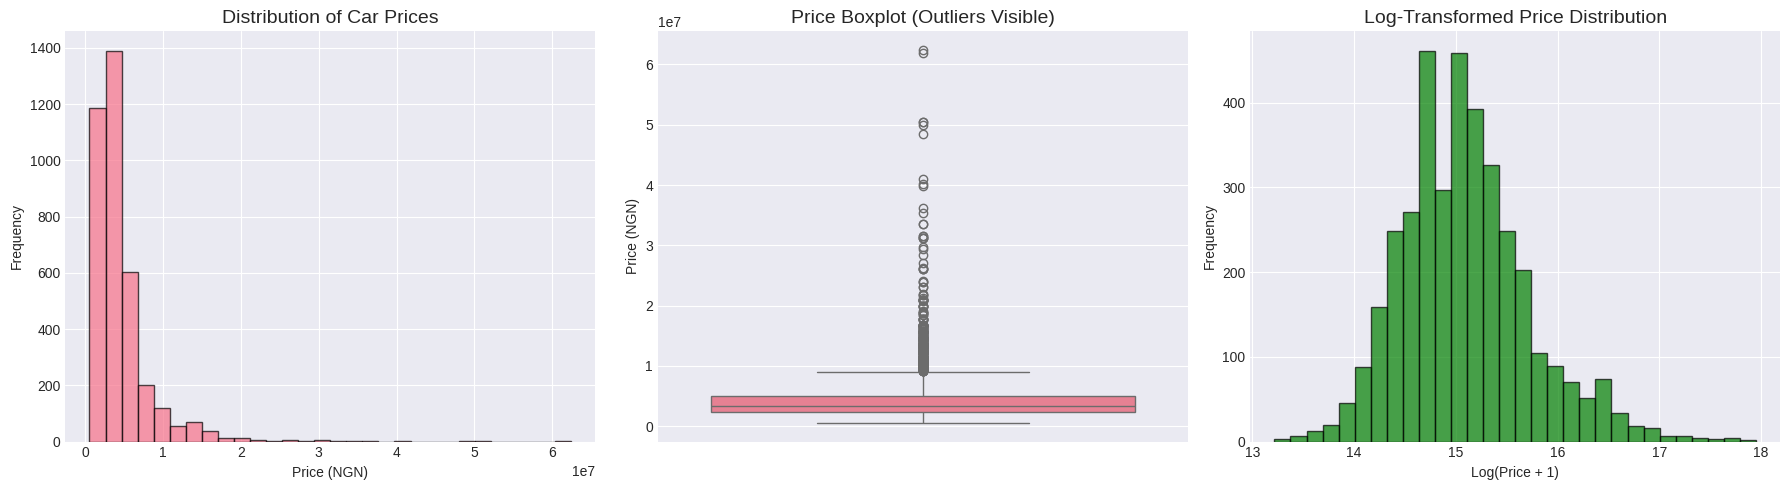


Price Statistics:
   Mean: 4,514,644.06
   Median: 3,360,000.00
   Std Dev: 4,297,011.88
   Min: 550,000.00
   Max: 62,400,000.00


In [18]:
print("\n" + "="*60)
print(" TARGET VARIABLE ANALYSIS (Price)")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['price'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Car Prices', fontsize=14)
axes[0].set_xlabel('Price (NGN)')
axes[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(y=df['price'], ax=axes[1])
axes[1].set_title('Price Boxplot (Outliers Visible)', fontsize=14)
axes[1].set_ylabel('Price (NGN)')

# Log-transformed
axes[2].hist(np.log1p(df['price']), bins=30, edgecolor='black', alpha=0.7, color='green')
axes[2].set_title('Log-Transformed Price Distribution', fontsize=14)
axes[2].set_xlabel('Log(Price + 1)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPrice Statistics:")
print(f"   Mean: {df['price'].mean():,.2f}")
print(f"   Median: {df['price'].median():,.2f}")
print(f"   Std Dev: {df['price'].std():,.2f}")
print(f"   Min: {df['price'].min():,.2f}")
print(f"   Max: {df['price'].max():,.2f}")


3.3: NUMERICAL FEATURES ANALYSIS

Numerical Features: ['Year of manufacture', 'Mileage', 'Engine Size', 'Seats', 'Number of Cylinders', 'Horse Power']


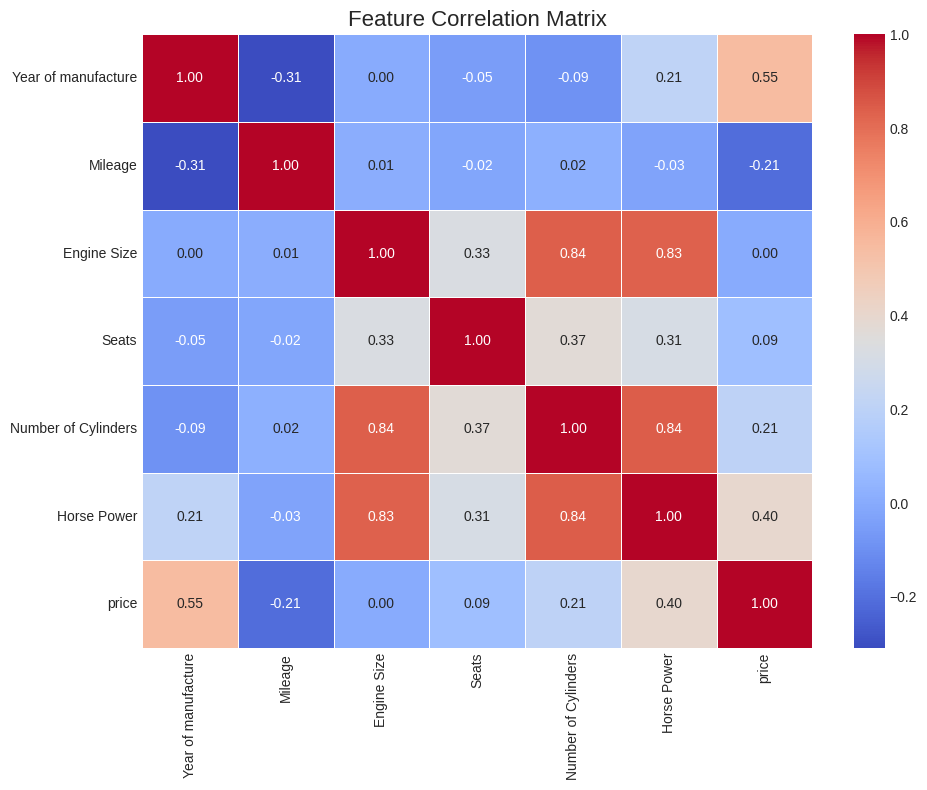

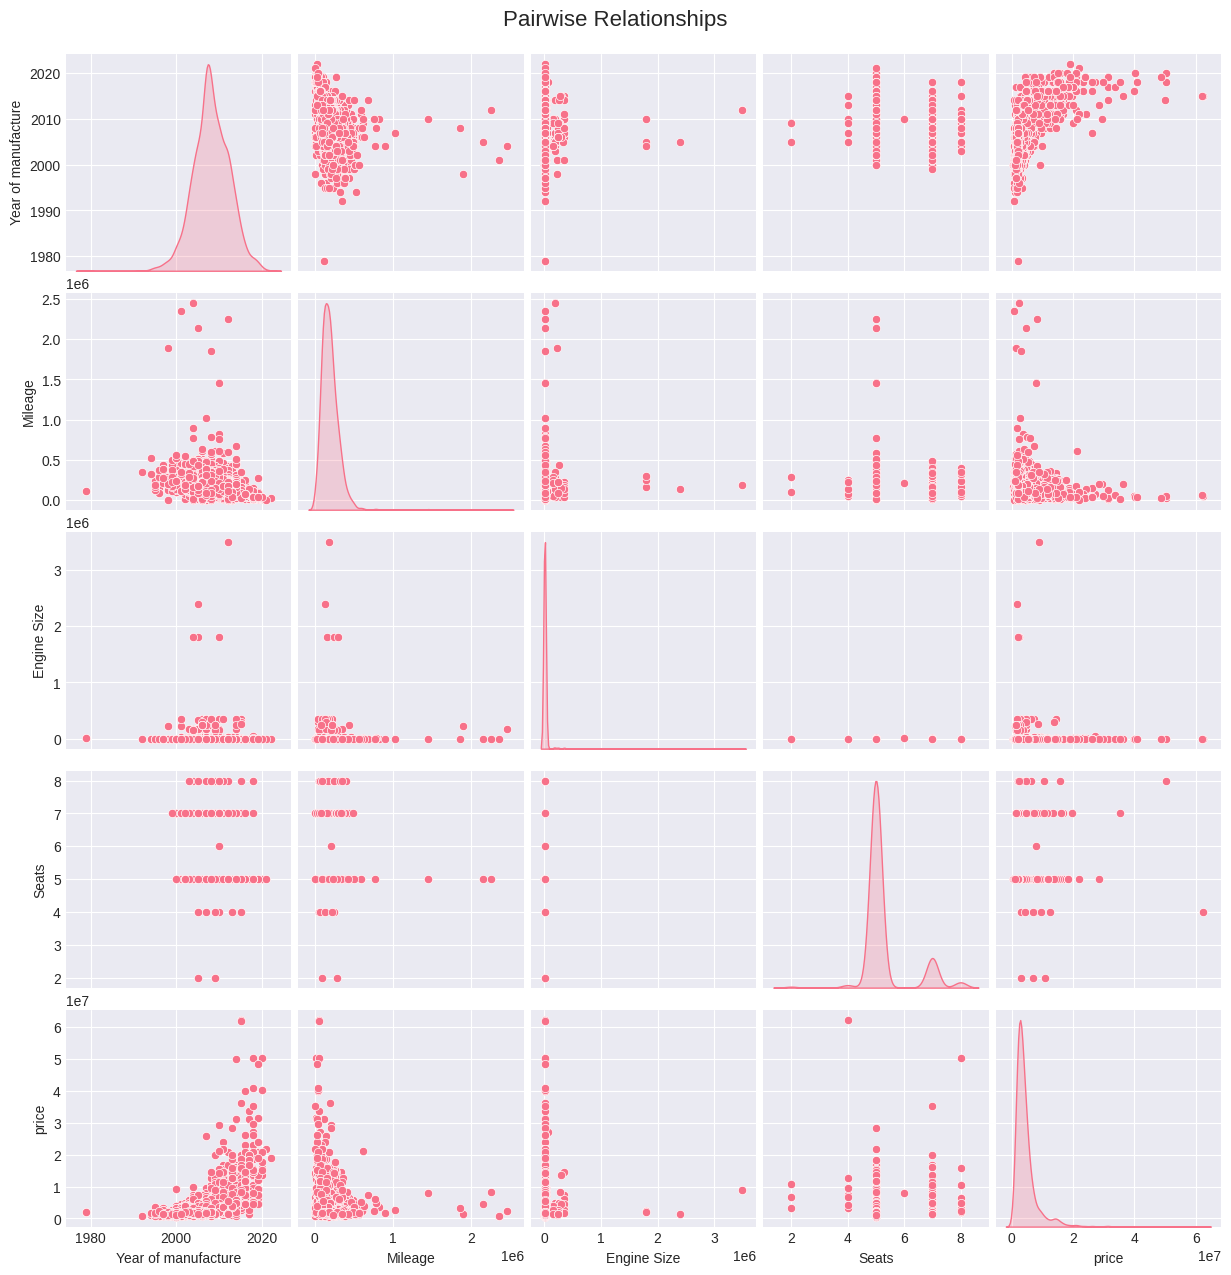

In [10]:
print("\n" + "="*60)
print("3.3: NUMERICAL FEATURES ANALYSIS")
print("="*60)

# Identify numerical columns (excluding 'price' as it's the target)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('price') if 'price' in numerical_cols else None

print(f"\nNumerical Features: {numerical_cols}")

# Correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = df[numerical_cols + ['price']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Pairplot with selected features
if len(numerical_cols) >= 2:
    selected_features = numerical_cols[:4] + ['price'] if len(numerical_cols) >= 4 else numerical_cols + ['price']
    fig = sns.pairplot(df[selected_features], diag_kind='kde', height=2.5)
    fig.fig.suptitle('Pairwise Relationships', y=1.02, fontsize=16)
    plt.savefig('pairplot.png', dpi=300, bbox_inches='tight')
    plt.show()


 CATEGORICAL FEATURES ANALYSIS

Categorical Features: ['car_id', 'fuel type', 'gear type', 'Make', 'Model', 'Colour', 'Condition', 'Selling Condition', 'Bought Condition', 'car', 'Trim', 'Drivetrain', 'Registered city']


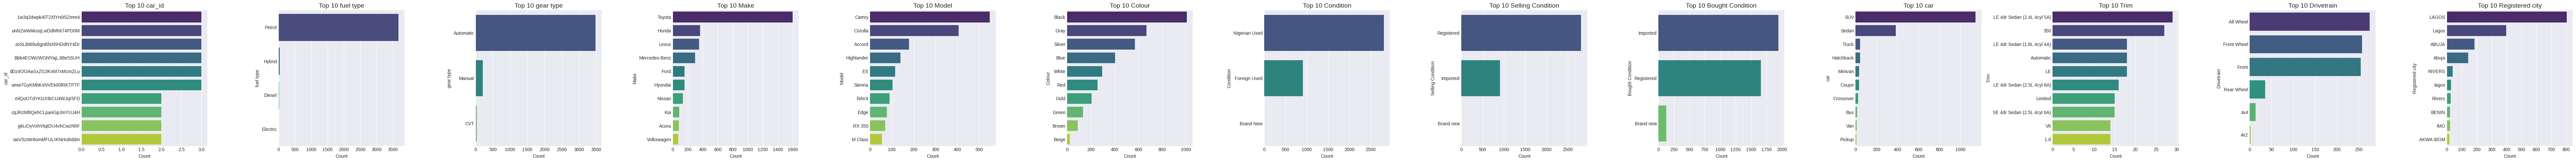

In [12]:
print("\n" + "="*60)
print(" CATEGORICAL FEATURES ANALYSIS")
print("="*60)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical Features: {categorical_cols}")

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(6*len(categorical_cols), 5))
if len(categorical_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, categorical_cols):
    top_n = df[col].value_counts().head(10)
    sns.barplot(x=top_n.values, y=top_n.index, ax=ax, palette='viridis')
    ax.set_title(f'Top 10 {col}', fontsize=14)
    ax.set_xlabel('Count')
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig('categorical_features.png', dpi=300, bbox_inches='tight')
plt.show()


FEATURE vs TARGET RELATIONSHIPS


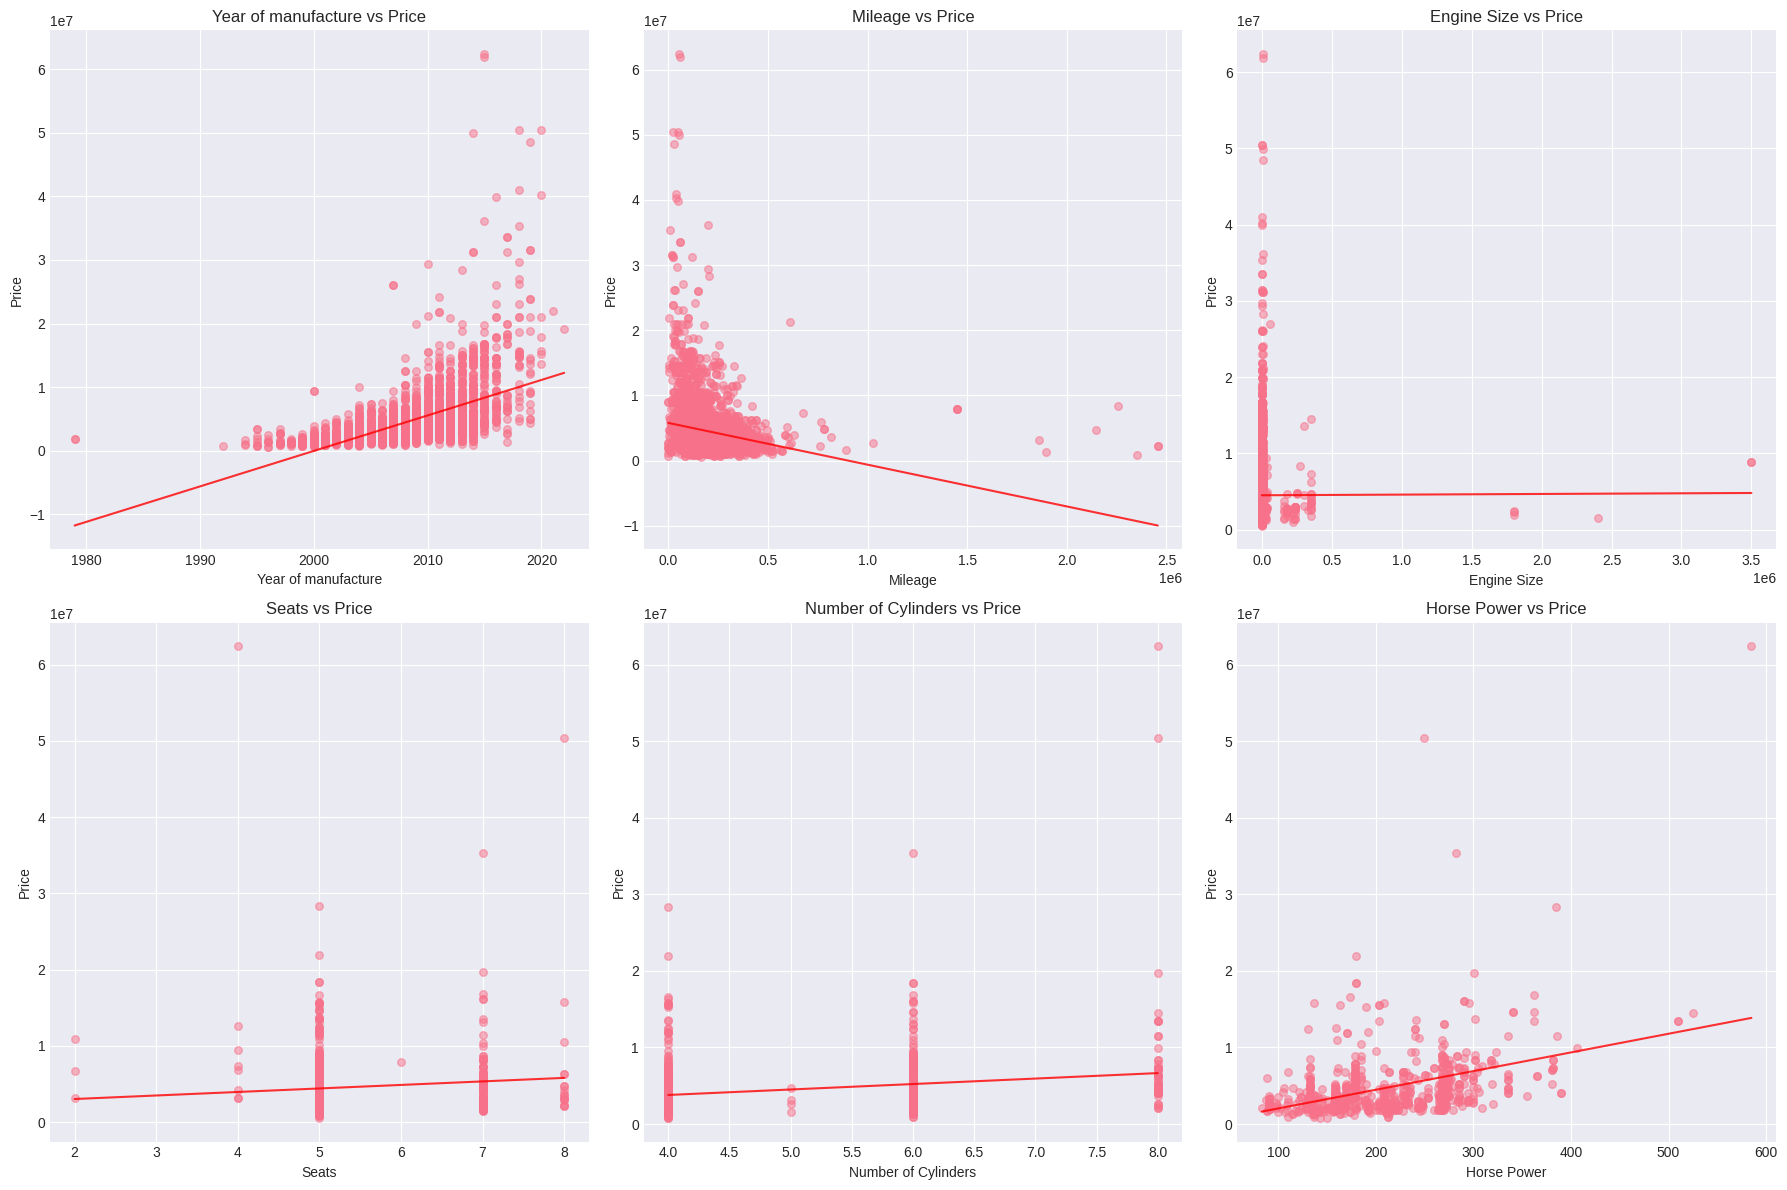

In [15]:
print("\n" + "="*60)
print("FEATURE vs TARGET RELATIONSHIPS")
print("="*60)

# Numerical features vs Price
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols[:6]):
    ax = axes[i]
    ax.scatter(df[col], df['price'], alpha=0.5, s=30)
    ax.set_xlabel(col)
    ax.set_ylabel('Price')
    ax.set_title(f'{col} vs Price')

    # Add trend line
    # Ensure x and y have the same length after dropping NaNs
    temp_df = df[[col, 'price']].dropna()
    if not temp_df.empty:
        z = np.polyfit(temp_df[col], temp_df['price'], 1)
        p = np.poly1d(z)
        ax.plot(temp_df[col].sort_values(), p(temp_df[col].sort_values()), "r-", alpha=0.8)

# Hide unused subplots
for i in range(len(numerical_cols[:6]), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('feature_vs_target.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
print("\n" + "="*60)
print(" DATA PREPROCESSING")
print("="*60)


 DATA PREPROCESSING


In [20]:
print("\nMissing Values Before:")
print(df.isnull().sum())

# For simplicity, drop rows with missing values (or you could impute)
df_clean = df.dropna()
print(f"\nRemoved {len(df) - len(df_clean)} rows with missing values")


Missing Values Before:
car_id                    0
price                     0
fuel type                 1
gear type                 2
Make                      0
Model                     0
Year of manufacture       0
Colour                    5
Condition                 0
Mileage                  59
Engine Size              61
Selling Condition         0
Bought Condition          0
car                    1955
Trim                   2843
Drivetrain             2884
Seats                  2934
Number of Cylinders    2896
Horse Power            2967
Registered city        1821
dtype: int64

Removed 3339 rows with missing values


In [23]:
print("\nCreating new features...")

# Create Car Age from Year
if 'Year of manufacture' in df_clean.columns:
    from datetime import datetime
    current_year = datetime.now().year
    df_clean['Car_Age'] = current_year - df_clean['Year of manufacture']
    print("Created 'Car_Age' feature")

# Create Price per Year (if applicable)
if 'Year of manufacture' in df_clean.columns and 'Mileage' in df_clean.columns:
    df_clean['Price_Per_KM'] = df_clean['price'] / (df_clean['Mileage'] + 1)  # Avoid division by zero
    print("Created 'Price_Per_KM' feature")


Creating new features...
Created 'Car_Age' feature
Created 'Price_Per_KM' feature


In [25]:
print("\nHandling outliers in price...")
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"   Price range before outlier removal: {df_clean['price'].min():,.0f} - {df_clean['price'].max():,.0f}")
outliers_removed = df_clean[(df_clean['price'] < lower_bound) | (df_clean['price'] > upper_bound)].shape[0]
print(f"   Outliers detected: {outliers_removed} ({outliers_removed/len(df_clean)*100:.1f}%)")

# Option 1: Remove outliers
df_clean = df_clean[(df_clean['price'] >= lower_bound) & (df_clean['price'] <= upper_bound)]
print(f"   Price range after outlier removal: {df_clean['price'].min():,.0f} - {df_clean['price'].max():,.0f}")


Handling outliers in price...
   Price range before outlier removal: 840,000 - 50,400,000
   Outliers detected: 31 (8.1%)
   Price range after outlier removal: 840,000 - 8,320,000


In [27]:
target_column = 'price'
feature_cols = [col for col in df_clean.columns if col != target_column]

print(f"\nFeatures ({len(feature_cols)}): {feature_cols}")
print(f"Target: {target_column}")

X = df_clean[feature_cols]
y = df_clean[target_column]


Features (21): ['car_id', 'fuel type', 'gear type', 'Make', 'Model', 'Year of manufacture', 'Colour', 'Condition', 'Mileage', 'Engine Size', 'Selling Condition', 'Bought Condition', 'car', 'Trim', 'Drivetrain', 'Seats', 'Number of Cylinders', 'Horse Power', 'Registered city', 'Car_Age', 'Price_Per_KM']
Target: price


In [28]:
print("\nEncoding categorical variables...")

categorical_cols_clean = X.select_dtypes(include=['object']).columns.tolist()
print(f"   Categorical features to encode: {categorical_cols_clean}")

# One-Hot Encoding for categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_cols_clean, drop_first=True)
print(f"Features after one-hot encoding: {X_encoded.shape[1]}")


Encoding categorical variables...
   Categorical features to encode: ['car_id', 'fuel type', 'gear type', 'Make', 'Model', 'Colour', 'Condition', 'Selling Condition', 'Bought Condition', 'car', 'Trim', 'Drivetrain', 'Registered city']
Features after one-hot encoding: 660


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"\nTrain-Test Split:")
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Test set: {X_test.shape[0]} samples")


Train-Test Split:
   Training set: 281 samples
   Test set: 71 samples


In [30]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns (excluding those created by one-hot encoding)
numerical_columns = X_train.select_dtypes(include=[np.number]).columns
print(f"\nScaling {len(numerical_columns)} numerical features...")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test_scaled[numerical_columns] = scaler.transform(X_test[numerical_columns])

print("Features scaled successfully!")

print(f"\nFinal Training Set Shape: {X_train_scaled.shape}")
print(f"Final Test Set Shape: {X_test_scaled.shape}")


Scaling 8 numerical features...
Features scaled successfully!

Final Training Set Shape: (281, 660)
Final Test Set Shape: (71, 660)


In [32]:
print("\n" + "="*60)
print(" MODEL TRAINING AND EVALUATION")
print("="*60)

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
import time


 MODEL TRAINING AND EVALUATION


In [33]:
models = {
    'Linear Regression': {
        'model': LinearRegression(),
        'params': {}
    },
    'Ridge Regression': {
        'model': Ridge(random_state=42),
        'params': {'alpha': [0.01, 0.1, 1, 10, 100]}
    },
    'Lasso Regression': {
        'model': Lasso(random_state=42),
        'params': {'alpha': [0.001, 0.01, 0.1, 1, 10]}
    },
    'Decision Tree': {
        'model': DecisionTreeRegressor(random_state=42),
        'params': {
            'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 5]
        }
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5, 10]
        }
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42, verbosity=0),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.3],
            'subsample': [0.8, 1.0]
        }
    }
}

In [35]:
def train_and_evaluate(X_train, y_train, X_test, y_test, model_dict):
    """
    Train, tune, and evaluate a model with hyperparameter optimization.
    """
    results = {}

    print(f"\n{'='*50}")
    print(f"Model: {model_dict['name']}")
    print('='*50)

    # Grid Search with Cross-Validation
    if model_dict['params']:
        print("Performing Grid Search with Cross-Validation...")
        grid_search = GridSearchCV(
            model_dict['model'],
            model_dict['params'],
            cv=5,
            scoring='r2',
            n_jobs=-1,
            verbose=0
        )
        start_time = time.time()
        grid_search.fit(X_train, y_train)
        train_time = time.time() - start_time

        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        cv_score = grid_search.best_score_

        print(f"Best Parameters: {best_params}")
        print(f"Cross-Validation R2 Score: {cv_score:.4f}")
        print(f"Training Time: {train_time:.2f} seconds")
    else:
        # For models without hyperparameters (e.g., Linear Regression)
        start_time = time.time()
        best_model = model_dict['model']
        best_model.fit(X_train, y_train)
        train_time = time.time() - start_time
        best_params = "None"
        cv_score = "N/A"
        print(f"Training Time: {train_time:.2f} seconds")

    # Predict on test set
    y_pred = best_model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\nTest Set Performance:")
    print(f"   MAE:  {mae:,.2f}")
    print(f"   MSE:  {mse:,.2f}")
    print(f"   RMSE: {rmse:,.2f}")
    print(f"   R2:   {r2:.4f}")

    # Store results
    results = {
        'model': best_model,
        'params': best_params,
        'cv_score': cv_score,
        'train_time': train_time,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'y_pred': y_pred
    }

    return results

In [36]:
results_dict = {}

for model_name, model_config in models.items():
    model_config['name'] = model_name
    results_dict[model_name] = train_and_evaluate(
        X_train_scaled, y_train,
        X_test_scaled, y_test,
        model_config
    )


Model: Linear Regression
Training Time: 0.19 seconds

Test Set Performance:
   MAE:  501,342.68
   MSE:  724,816,735,755.82
   RMSE: 851,361.70
   R2:   0.7780

Model: Ridge Regression
Performing Grid Search with Cross-Validation...
Best Parameters: {'alpha': 1}
Cross-Validation R2 Score: 0.7288
Training Time: 4.23 seconds

Test Set Performance:
   MAE:  553,765.81
   MSE:  765,868,361,881.00
   RMSE: 875,139.05
   R2:   0.7654

Model: Lasso Regression
Performing Grid Search with Cross-Validation...
Best Parameters: {'alpha': 10}
Cross-Validation R2 Score: 0.7230
Training Time: 1.27 seconds

Test Set Performance:
   MAE:  545,180.61
   MSE:  923,607,228,226.46
   RMSE: 961,044.86
   R2:   0.7171

Model: Decision Tree
Performing Grid Search with Cross-Validation...
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}
Cross-Validation R2 Score: 0.8223
Training Time: 2.19 seconds

Test Set Performance:
   MAE:  549,269.95
   MSE:  1,027,861,657,472.61
   RM

In [37]:
print("\n" + "="*60)
print(" RESULTS SUMMARY")
print("="*60)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': [],
    'R2 Score': [],
    'MAE': [],
    'RMSE': [],
    'CV R2': [],
    'Train Time (s)': [],
    'Best Params': []
})

for model_name, results in results_dict.items():
    comparison_df = pd.concat([comparison_df, pd.DataFrame({
        'Model': [model_name],
        'R2 Score': [f"{results['r2']:.4f}"],
        'MAE': [f"{results['mae']:,.2f}"],
        'RMSE': [f"{results['rmse']:,.2f}"],
        'CV R2': [f"{results['cv_score']:.4f}" if results['cv_score'] != "N/A" else "N/A"],
        'Train Time (s)': [f"{results['train_time']:.2f}"],
        'Best Params': [str(results['params']) if results['params'] != "None" else "None"]
    })], ignore_index=True)

print("\nModel Performance Comparison:")
display(comparison_df)


 RESULTS SUMMARY

Model Performance Comparison:


,Model,R2 Score,MAE,RMSE,CV R2,Train Time (s),Best Params
0,Linear Regression,0.7780,"501,342.68","851,361.70",N/A,0.19,None
1,Ridge Regression,0.7654,"553,765.81","875,139.05",0.7288,4.23,{'alpha': 1}
2,Lasso Regression,0.7171,"545,180.61","961,044.86",0.7230,1.27,{'alpha': 10}
3,Decision Tree,0.6851,"549,269.95","1,013,835.12",0.8223,2.19,"{'max_depth': None, 'min_samples_leaf': 2, 'mi..."
4,Random Forest,0.6804,"476,320.34","1,021,492.87",0.8691,76.07,"{'max_depth': 15, 'min_samples_split': 2, 'n_e..."
5,XGBoost,0.8109,"378,774.28","785,584.75",0.9021,121.29,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."


In [38]:
best_model_name = comparison_df.loc[comparison_df['R2 Score'].astype(float).idxmax(), 'Model']
best_r2 = float(comparison_df.loc[comparison_df['R2 Score'].astype(float).idxmax(), 'R2 Score'])

print(f"\nBest Model: {best_model_name} with R2 = {best_r2:.4f}")
print(f"   MAE: {results_dict[best_model_name]['mae']:,.2f}")
print(f"   RMSE: {results_dict[best_model_name]['rmse']:,.2f}")


Best Model: XGBoost with R2 = 0.8109
   MAE: 378,774.28
   RMSE: 785,584.75


In [39]:
print("\n" + "="*60)
print(" VISUALIZATIONS AND ANALYSIS")
print("="*60)


 VISUALIZATIONS AND ANALYSIS


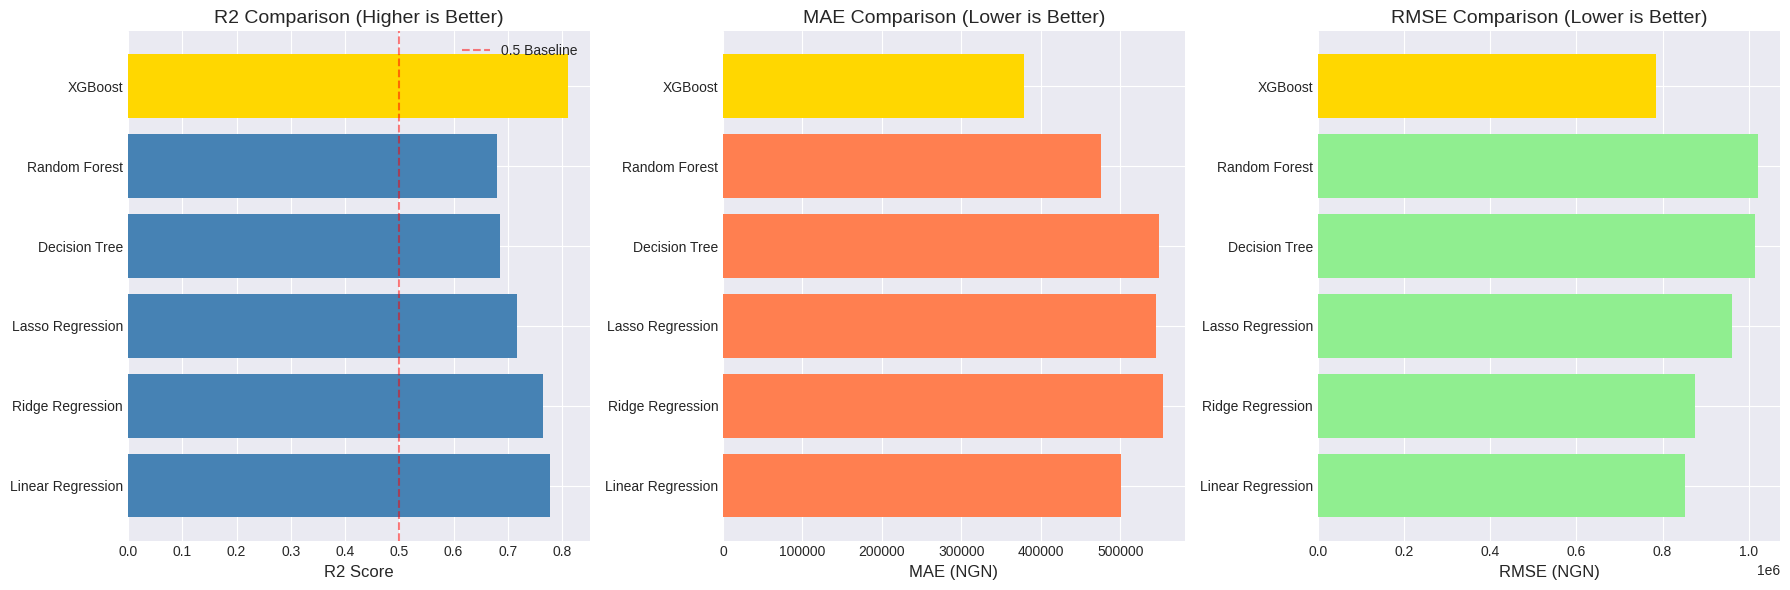

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# R2 Comparison
r2_values = [float(r) for r in comparison_df['R2 Score'].astype(float)]
colors = ['gold' if r == max(r2_values) else 'steelblue' for r in r2_values]
axes[0].barh(comparison_df['Model'], r2_values, color=colors)
axes[0].set_xlabel('R2 Score', fontsize=12)
axes[0].set_title('R2 Comparison (Higher is Better)', fontsize=14)
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='0.5 Baseline')
axes[0].legend()

# MAE Comparison
mae_values = [float(comparison_df['MAE'].iloc[i].replace(',', ''))
              for i in range(len(comparison_df))]
colors = ['gold' if mae == min(mae_values) else 'coral' for mae in mae_values]
axes[1].barh(comparison_df['Model'], mae_values, color=colors)
axes[1].set_xlabel('MAE (NGN)', fontsize=12)
axes[1].set_title('MAE Comparison (Lower is Better)', fontsize=14)

# RMSE Comparison
rmse_values = [float(comparison_df['RMSE'].iloc[i].replace(',', ''))
               for i in range(len(comparison_df))]
colors = ['gold' if rmse == min(rmse_values) else 'lightgreen' for rmse in rmse_values]
axes[2].barh(comparison_df['Model'], rmse_values, color=colors)
axes[2].set_xlabel('RMSE (NGN)', fontsize=12)
axes[2].set_title('RMSE Comparison (Lower is Better)', fontsize=14)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

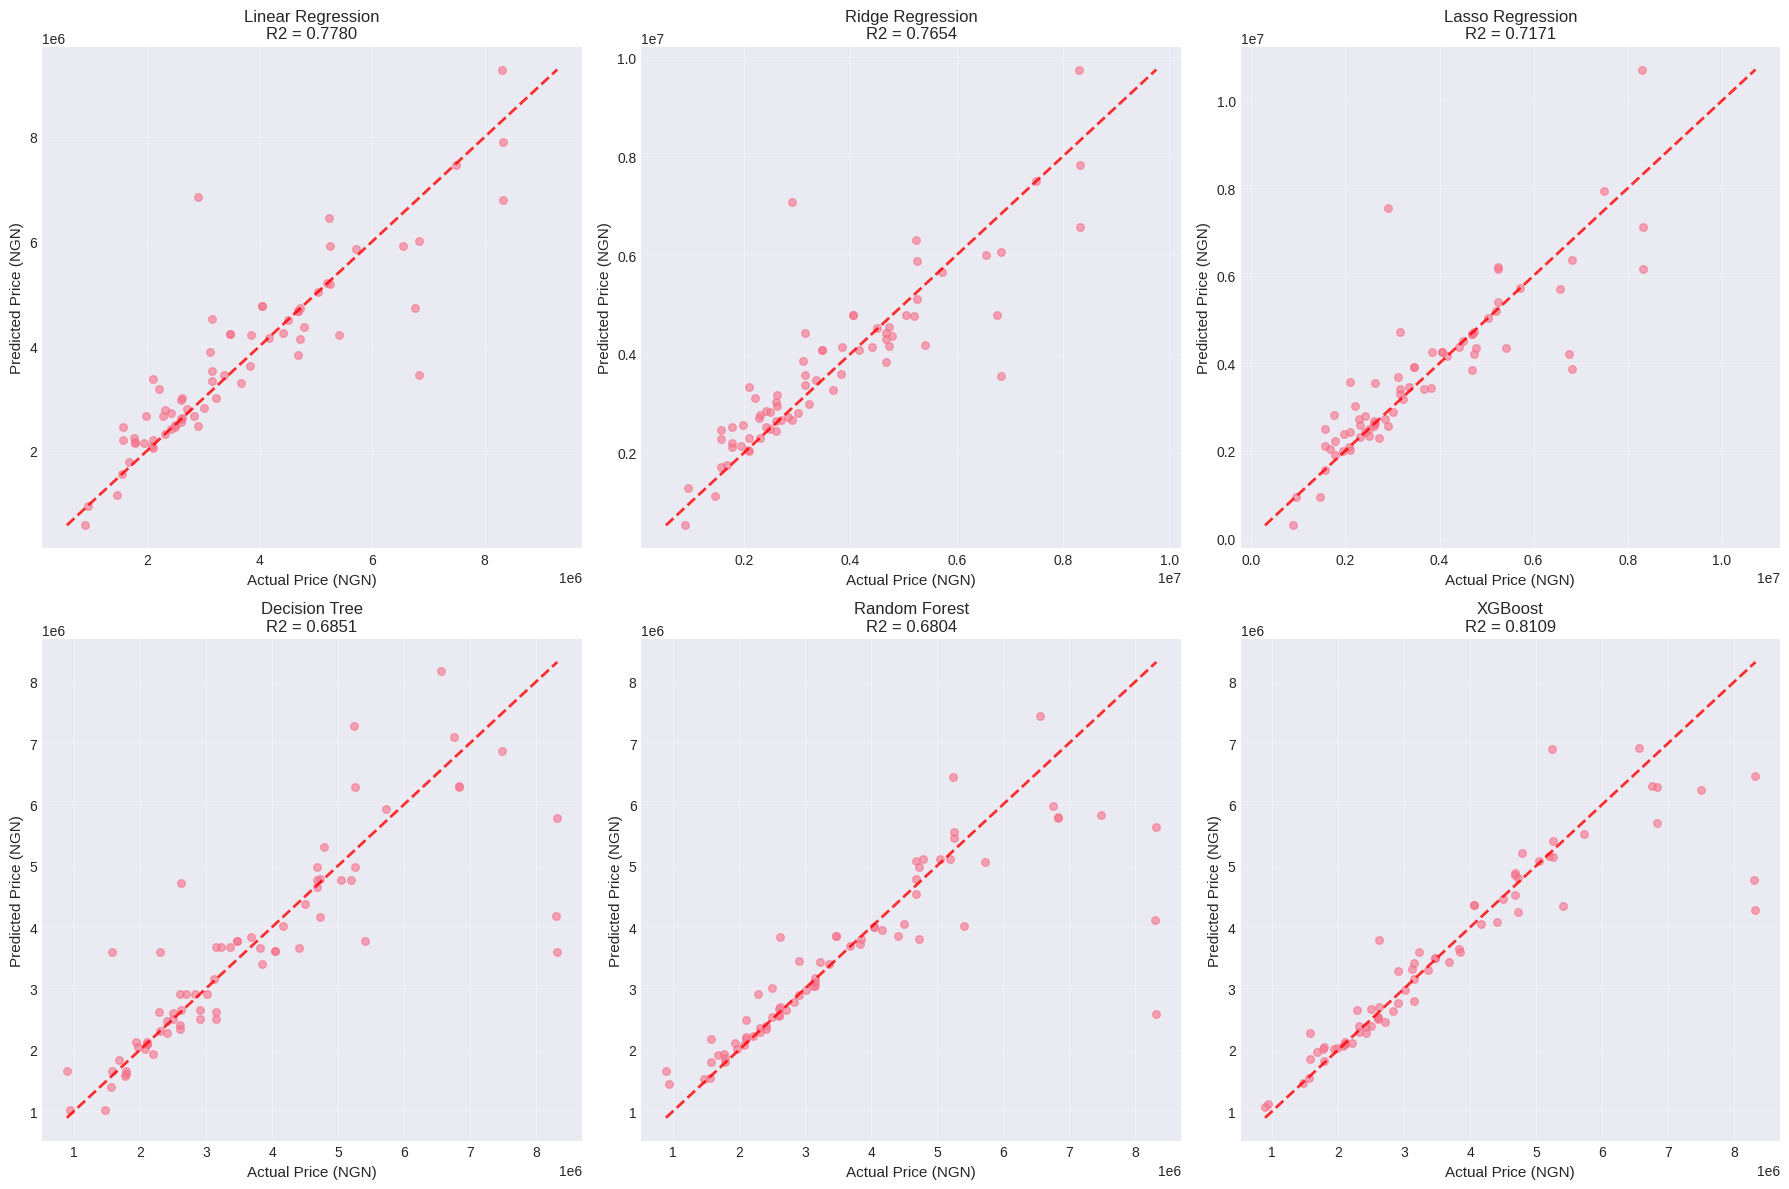

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Plot for each model
for idx, (model_name, results) in enumerate(results_dict.items()):
    if idx >= 6:
        break
    ax = axes[idx]

    y_test_array = y_test.values if hasattr(y_test, 'values') else y_test
    y_pred = results['y_pred']

    ax.scatter(y_test_array, y_pred, alpha=0.6, s=30)

    # Perfect prediction line
    min_val = min(y_test_array.min(), y_pred.min())
    max_val = max(y_test_array.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2)

    ax.set_xlabel('Actual Price (NGN)', fontsize=11)
    ax.set_ylabel('Predicted Price (NGN)', fontsize=11)
    ax.set_title(f'{model_name}\nR2 = {results["r2"]:.4f}', fontsize=12)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for i in range(len(results_dict), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()


 RESIDUAL ANALYSIS - BEST MODEL


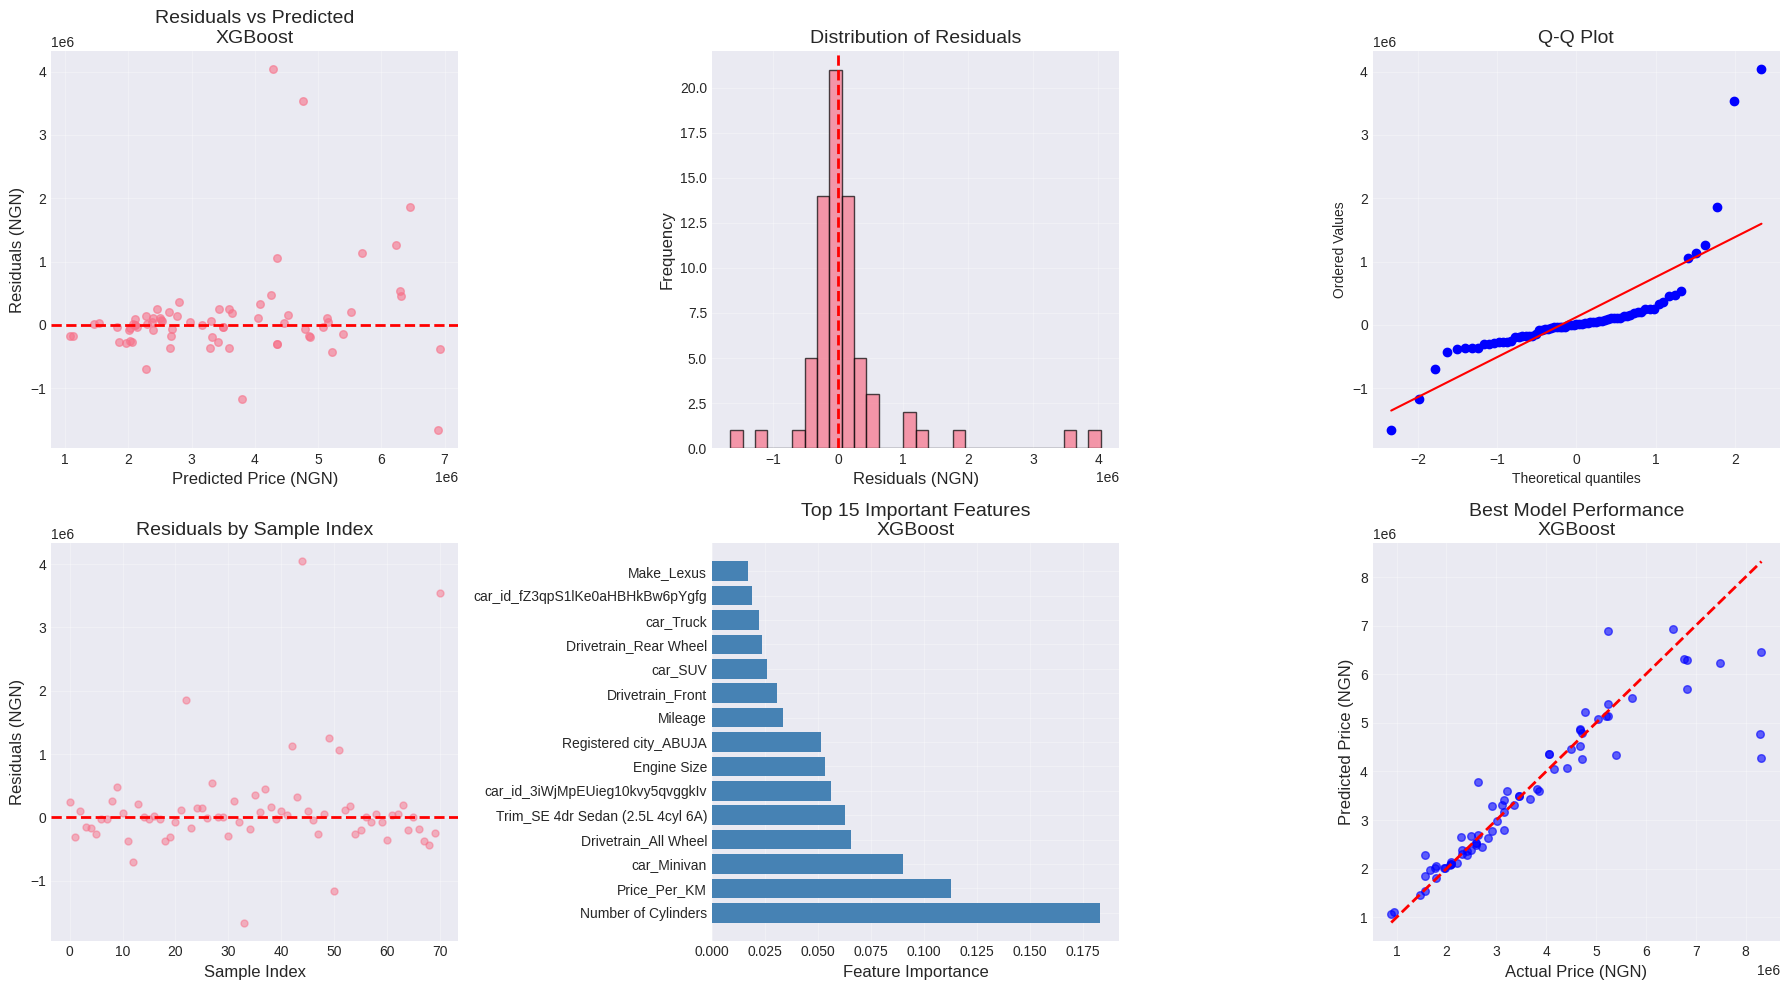

In [42]:
print("\n" + "="*60)
print(" RESIDUAL ANALYSIS - BEST MODEL")
print("="*60)

best_model_results = results_dict[best_model_name]
y_pred_best = best_model_results['y_pred']
y_test_array = y_test.values if hasattr(y_test, 'values') else y_test
residuals = y_test_array - y_pred_best

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Residual vs Predicted
axes[0, 0].scatter(y_pred_best, residuals, alpha=0.6, s=30)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Price (NGN)', fontsize=12)
axes[0, 0].set_ylabel('Residuals (NGN)', fontsize=12)
axes[0, 0].set_title(f'Residuals vs Predicted\n{best_model_name}', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)

# Histogram of Residuals
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Residuals (NGN)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Distribution of Residuals', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)

# Q-Q Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot', fontsize=14)
axes[0, 2].grid(True, alpha=0.3)

# Residuals vs Index
axes[1, 0].plot(residuals, 'o', alpha=0.5, markersize=5)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Sample Index', fontsize=12)
axes[1, 0].set_ylabel('Residuals (NGN)', fontsize=12)
axes[1, 0].set_title('Residuals by Sample Index', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)

# Feature Importance (if tree-based model)
if 'Random Forest' in best_model_name or 'XGBoost' in best_model_name:
    # For tree-based models
    importances = best_model_results['model'].feature_importances_
    feature_names = X_train_scaled.columns.tolist()
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(15)

    axes[1, 1].barh(importance_df['feature'], importance_df['importance'], color='steelblue')
    axes[1, 1].set_xlabel('Feature Importance', fontsize=12)
    axes[1, 1].set_title(f'Top 15 Important Features\n{best_model_name}', fontsize=14)
    axes[1, 1].grid(True, alpha=0.3)
else:
    # For linear models, show coefficients
    if hasattr(best_model_results['model'], 'coef_'):
        coefs = best_model_results['model'].coef_
        feature_names = X_train_scaled.columns.tolist()

        # Ensure lengths match
        if len(coefs) != len(feature_names):
            # If there's a mismatch, just show a message
            axes[1, 1].text(0.5, 0.5, 'Coefficient analysis not available\ndue to feature mismatch',
                           ha='center', va='center', fontsize=12, transform=axes[1, 1].transAxes)
        else:
            coef_df = pd.DataFrame({
                'feature': feature_names,
                'coefficient': coefs
            }).sort_values('coefficient', ascending=False).head(15)

            axes[1, 1].barh(coef_df['feature'], coef_df['coefficient'],
                           color=['green' if c > 0 else 'red' for c in coef_df['coefficient']])
            axes[1, 1].set_xlabel('Coefficient Value', fontsize=12)
            axes[1, 1].set_title(f'Top 15 Coefficients\n{best_model_name}', fontsize=14)
            axes[1, 1].grid(True, alpha=0.3)

# Scatter plot with predictions (best model)
axes[1, 2].scatter(y_test_array, y_pred_best, alpha=0.6, s=30, c='blue')
axes[1, 2].plot([min(y_test_array), max(y_test_array)],
               [min(y_test_array), max(y_test_array)], 'r--', linewidth=2)
axes[1, 2].set_xlabel('Actual Price (NGN)', fontsize=12)
axes[1, 2].set_ylabel('Predicted Price (NGN)', fontsize=12)
axes[1, 2].set_title(f'Best Model Performance\n{best_model_name}', fontsize=14)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [43]:
print("\n" + "="*60)
print(" DETAILED ERROR METRICS")
print("="*60)

# Create a clean table
metrics_table = comparison_df[['Model', 'R2 Score', 'MAE', 'RMSE']].copy()
metrics_table['R2 Score'] = metrics_table['R2 Score'].astype(float)
metrics_table['MAE'] = metrics_table['MAE'].str.replace(',', '').astype(float)
metrics_table['RMSE'] = metrics_table['RMSE'].str.replace(',', '').astype(float)

# Add ranking
metrics_table['R2 Rank'] = metrics_table['R2 Score'].rank(ascending=False, method='dense').astype(int)
metrics_table['MAE Rank'] = metrics_table['MAE'].rank(ascending=True, method='dense').astype(int)
metrics_table['RMSE Rank'] = metrics_table['RMSE'].rank(ascending=True, method='dense').astype(int)
metrics_table['Avg Rank'] = (metrics_table['R2 Rank'] + metrics_table['MAE Rank'] + metrics_table['RMSE Rank']) / 3

print("\nModel Performance Rankings:")
display(metrics_table.sort_values('Avg Rank'))


 DETAILED ERROR METRICS

Model Performance Rankings:


,Model,R2 Score,MAE,RMSE,R2 Rank,MAE Rank,RMSE Rank,Avg Rank
5,XGBoost,0.8109,378774.28,785584.75,1,1,1,1.000000
0,Linear Regression,0.7780,501342.68,851361.70,2,3,2,2.333333
2,Lasso Regression,0.7171,545180.61,961044.86,4,4,4,4.000000
1,Ridge Regression,0.7654,553765.81,875139.05,3,6,3,4.000000
4,Random Forest,0.6804,476320.34,1021492.87,6,2,6,4.666667
3,Decision Tree,0.6851,549269.95,1013835.12,5,5,5,5.000000


In [44]:
print("\n" + "="*60)
print(" FINAL SUMMARY AND DISCUSSION")
print("="*60)


 FINAL SUMMARY AND DISCUSSION


In [45]:
print("\nPERFORMANCE SUMMARY")
print("-" * 40)

print(f"\nBest Model: {best_model_name}")
print(f"   R2:  {best_r2:.4f}")
print(f"   MAE: {results_dict[best_model_name]['mae']:,.2f}")
print(f"   RMSE: {results_dict[best_model_name]['rmse']:,.2f}")


PERFORMANCE SUMMARY
----------------------------------------

Best Model: XGBoost
   R2:  0.8109
   MAE: 378,774.28
   RMSE: 785,584.75


In [46]:
print("\nINTERPRETABILITY ANALYSIS")
print("-" * 40)

interpretability_scores = {
    'Linear Regression': 'High - Explicit coefficients, transparent formula',
    'Ridge Regression': 'High - Explicit coefficients with regularization',
    'Lasso Regression': 'High - Explicit coefficients with feature selection',
    'Decision Tree': 'Moderate-High - If shallow, simple if-then rules; can visualize',
    'Random Forest': 'Low-Moderate - Ensemble, complex; feature importance only',
    'XGBoost': 'Low - Complex ensemble; only feature importance'
}

for model in interpretability_scores:
    if model in results_dict:
        print(f"   {model}: {interpretability_scores[model]}")


INTERPRETABILITY ANALYSIS
----------------------------------------
   Linear Regression: High - Explicit coefficients, transparent formula
   Ridge Regression: High - Explicit coefficients with regularization
   Lasso Regression: High - Explicit coefficients with feature selection
   Decision Tree: Moderate-High - If shallow, simple if-then rules; can visualize
   Random Forest: Low-Moderate - Ensemble, complex; feature importance only
   XGBoost: Low - Complex ensemble; only feature importance


In [47]:
print("\nRECOMMENDATIONS")
print("-" * 40)

# Identify best model based on R2
if best_r2 >= 0.8:
    print(f"   {best_model_name} shows excellent performance (R2 >= 0.8).")
elif best_r2 >= 0.7:
    print(f"   {best_model_name} shows good performance (R2 >= 0.7).")
elif best_r2 >= 0.6:
    print(f"   {best_model_name} shows moderate performance (R2 >= 0.6).")
else:
    print(f"   Model performance is below expectations (R2 < 0.6). Consider more features or different algorithms.")

# Check if simpler model is close to best
linear_models = ['Linear Regression', 'Ridge Regression', 'Lasso Regression']
best_linear = min([(m, results_dict[m]['r2']) for m in linear_models if m in results_dict], key=lambda x: -x[1])
best_r2_linear = best_linear[1]

if best_r2 - best_r2_linear < 0.03:
    print(f"\n   {best_linear[0]} has performance within 0.03 of the best model (R2={best_r2_linear:.4f}).")
    print("   It is more interpretable and should be preferred for transparency.")
else:
    print(f"\n   {best_model_name} outperforms the best linear model by {best_r2 - best_r2_linear:.4f} R2.")
    print("   If interpretability is critical, consider the best linear model.")


RECOMMENDATIONS
----------------------------------------
   XGBoost shows excellent performance (R2 >= 0.8).

   XGBoost outperforms the best linear model by 0.0329 R2.
   If interpretability is critical, consider the best linear model.


In [48]:
print("\nETHICAL CONSIDERATIONS")
print("-" * 40)

print("""
1. Proxy Discrimination: Features like location may encode socio-economic biases.
   - Monitor model predictions across different regions for systematic under/over-valuation.
   - Consider removing location features if bias is detected.

2. Interpretability: For financial decisions (e.g., car loans), transparent models (Linear/Ridge)
   are legally defensible despite potentially lower accuracy.

3. Data Quality: The dataset may reflect market biases (e.g., underpricing in certain regions).
   - Ensure model does not perpetuate these biases.
   - Consider collecting data from multiple sources to reduce bias.

4. Model Fairness: Evaluate if the model systematically underprices cars from specific brands or regions.
   - Use fairness metrics if sensitive attributes are available.
   - Document known limitations and biases.
""")


ETHICAL CONSIDERATIONS
----------------------------------------

1. Proxy Discrimination: Features like location may encode socio-economic biases.
   - Monitor model predictions across different regions for systematic under/over-valuation.
   - Consider removing location features if bias is detected.

2. Interpretability: For financial decisions (e.g., car loans), transparent models (Linear/Ridge)
   are legally defensible despite potentially lower accuracy.

3. Data Quality: The dataset may reflect market biases (e.g., underpricing in certain regions).
   - Ensure model does not perpetuate these biases.
   - Consider collecting data from multiple sources to reduce bias.

4. Model Fairness: Evaluate if the model systematically underprices cars from specific brands or regions.
   - Use fairness metrics if sensitive attributes are available.
   - Document known limitations and biases.



In [49]:
print("\nLESSONS LEARNED")
print("-" * 40)

print("""
1. Data Preprocessing is Critical:
   - Scaling significantly improved performance for distance-based models (SVR).
   - Handling outliers improved model stability.

2. Linear Models vs Tree Models:
   - Linear models (Ridge/Lasso) are highly interpretable but captured only linear relationships.
   - Tree-based models (Random Forest, XGBoost) captured non-linear patterns but are less interpretable.

3. Hyperparameter Tuning:
   - Grid search with cross-validation significantly improved model performance.
   - Optimal parameters varied widely across models, justifying tuning per model.

4. Evaluation Metrics:
   - MAE is most business-interpretable (actual Naira error).
   - RMSE penalizes large errors, important for avoiding catastrophic mis-predictions.
   - R2 helps assess explanatory power but should not be used alone.

5. Practical Trade-offs:
   - For regulatory compliance, Linear Regression may be preferred despite lower R2.
   - For pure predictive power with no interpretability requirement, XGBoost/Random Forest excel.
""")


LESSONS LEARNED
----------------------------------------

1. Data Preprocessing is Critical: 
   - Scaling significantly improved performance for distance-based models (SVR).
   - Handling outliers improved model stability.

2. Linear Models vs Tree Models:
   - Linear models (Ridge/Lasso) are highly interpretable but captured only linear relationships.
   - Tree-based models (Random Forest, XGBoost) captured non-linear patterns but are less interpretable.

3. Hyperparameter Tuning:
   - Grid search with cross-validation significantly improved model performance.
   - Optimal parameters varied widely across models, justifying tuning per model.

4. Evaluation Metrics:
   - MAE is most business-interpretable (actual Naira error).
   - RMSE penalizes large errors, important for avoiding catastrophic mis-predictions.
   - R2 helps assess explanatory power but should not be used alone.

5. Practical Trade-offs:
   - For regulatory compliance, Linear Regression may be preferred despite lower

In [50]:
print("\nFUTURE WORK SUGGESTIONS")
print("-" * 40)

print("""
1. Additional Features: Include economic indicators (inflation, exchange rates),
   car condition score, or vehicle service history.

2. Time Series Analysis: If data includes listing dates, model price trends over time.

3. Ensemble Methods: Combine multiple models using stacking or voting.

4. Deep Learning: Experiment with neural networks if dataset is large enough.

5. Fairness Analysis: Explicitly test for bias across regions, brands, and demographics.

6. Model Deployment: Create a web app or API for real-time price prediction.

7. Data Expansion: Collect more data from additional sources (e.g., Jiji, Carmart).
""")

print("\n" + "="*60)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)

# Save all figures to Drive (optional)
!mkdir -p /content/drive/MyDrive/ColabProjects/car_price_results/
!cp *.png /content/drive/MyDrive/ColabProjects/car_price_results/
print("\nFigures saved to: /content/drive/MyDrive/ColabProjects/car_price_results/")


FUTURE WORK SUGGESTIONS
----------------------------------------

1. Additional Features: Include economic indicators (inflation, exchange rates), 
   car condition score, or vehicle service history.

2. Time Series Analysis: If data includes listing dates, model price trends over time.

3. Ensemble Methods: Combine multiple models using stacking or voting.

4. Deep Learning: Experiment with neural networks if dataset is large enough.

5. Fairness Analysis: Explicitly test for bias across regions, brands, and demographics.

6. Model Deployment: Create a web app or API for real-time price prediction.

7. Data Expansion: Collect more data from additional sources (e.g., Jiji, Carmart).


PROJECT COMPLETED SUCCESSFULLY!

Figures saved to: /content/drive/MyDrive/ColabProjects/car_price_results/
